<a href="https://colab.research.google.com/github/pritishma-shakya/ai-and-machine-learning/blob/main/PritishmaShakya_2408412_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

6 Simple CNN Implemented using Keras.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9623 - loss: 0.1241 - val_accuracy: 0.9865 - val_loss: 0.0434
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9865 - loss: 0.0434 - val_accuracy: 0.9877 - val_loss: 0.0345
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9907 - loss: 0.0296 - val_accuracy: 0.9898 - val_loss: 0.0301
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9929 - loss: 0.0221 - val_accuracy: 0.9921 - val_loss: 0.0263
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9945 - loss: 0.0170 - val_accuracy: 0.9915 - val_loss: 0.0302
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9915 - loss: 0.0302
Test accuracy: 0.9915
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


7 Exercise.

Implement an End to End CNN Model for Image Classification Task.

Task 1: Data Understanding and Visualization:

In [ ]:
import tensorflow as tf
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report


print(tf.__version__)
print(tf.keras.__version__)

2.19.0
3.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


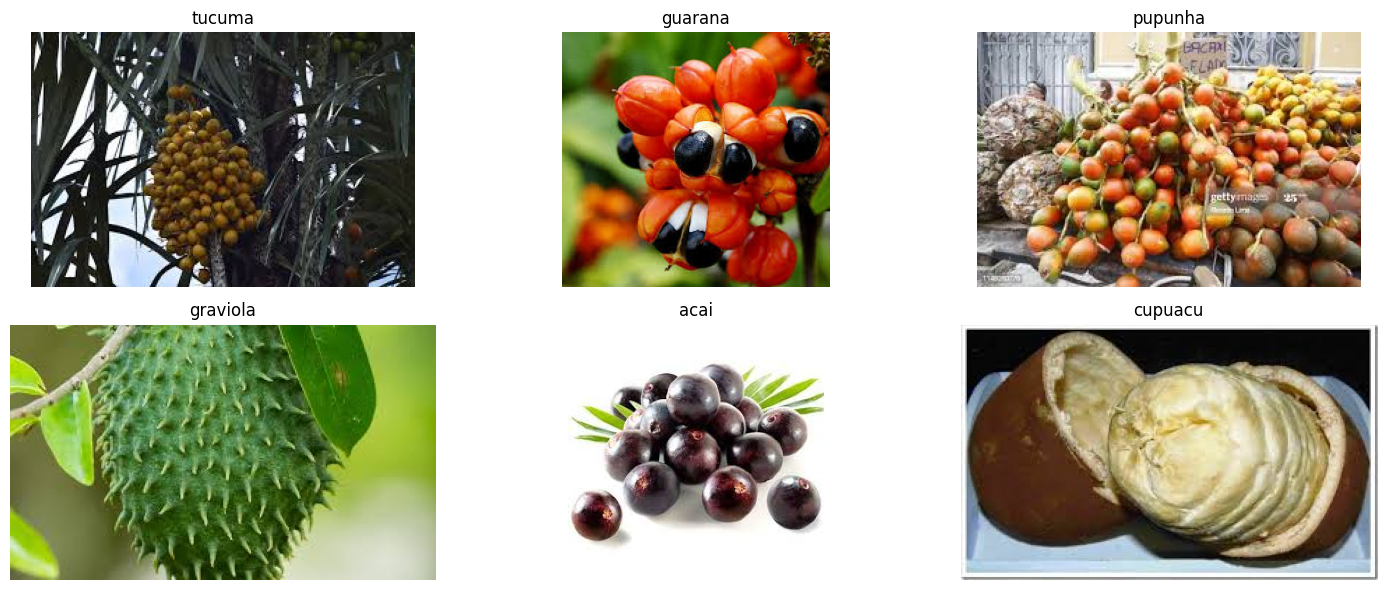

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset path
train_dir = "/content/drive/MyDrive/Sem6AI/FruitinAmazon/FruitinAmazon/train/"
test_dir = "/content/drive/MyDrive/Sem6AI/FruitinAmazon/FruitinAmazon/test/"

# 1. Get list of class directories
class_names = [d for d in os.listdir(train_dir)
               if os.path.isdir(os.path.join(train_dir, d))]

# 2. Select one random image from each class
images = []
labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    img_files = os.listdir(class_path)

    # Filter valid image files
    img_files = [f for f in img_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(img_files) == 0:
        continue

    # Pick random image
    img_name = random.choice(img_files)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)  # keep RGB for fruits
    images.append(img)
    labels.append(class_name)

# 3. Display images in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # ensure 2 rows

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

2. Check for Corrupted Image:

In [ ]:
corrupted_images = []

# Use your variable: class_names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for fname in os.listdir(class_path):
        image_path = os.path.join(class_path, fname)

        # Only check image files
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        try:
            # First check (quick verification)
            with Image.open(image_path) as img:
                img.verify()

            # Second check (fully load image)
            with Image.open(image_path) as img:
                img.load()

        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final result
if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3 - Implement a CNN with

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Task 4: Compile and Train the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.1348 - loss: 1.8350

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 0.1389 - loss: 1.8426 - val_accuracy: 0.2778 - val_loss: 1.4183
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.3513 - loss: 1.6032

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step - accuracy: 0.3194 - loss: 1.6189 - val_accuracy: 0.4444 - val_loss: 1.3974
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4034 - loss: 1.4144

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 325ms/step - accuracy: 0.4444 - loss: 1.3747 - val_accuracy: 0.6667 - val_loss: 1.3100
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5642 - loss: 1.2352

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.5833 - loss: 1.1953 - val_accuracy: 0.6111 - val_loss: 1.1669
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7662 - loss: 0.9334

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 577ms/step - accuracy: 0.8750 - loss: 0.5357 - val_accuracy: 0.8889 - val_loss: 0.6770
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9363 - loss: 0.3287

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.9028 - loss: 0.3649 - val_accuracy: 0.8889 - val_loss: 0.4140
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.9583 - loss: 0.2777 - val_accuracy: 0.8333 - val_loss: 0.6246
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.9722 - loss: 0.1587 - val_accuracy: 0.8333 - val_loss: 0.6446
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 0.9861 - loss: 0.1383 - val_accuracy: 0.8333 - val_loss: 0.4322
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9902 - loss: 0.0677

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.9861 - loss: 0.0706 - val_accuracy: 0.8333 - val_loss: 0.3701
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 1.0000 - loss: 0.0386 - val_accuracy: 0.8333 - val_loss: 0.3722
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 1.0000 - loss: 0.0260 - val_accuracy: 0.8333 - val_loss: 0.3948
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.8333 - val_loss: 0.3990
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.8333 - val_loss: 0.3997
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.8333 - val_loss: 0.4033
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.8333 - val_loss: 0.3954
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.8333 - val_lo

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.8333 - val_loss: 0.3519
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 1.0000 - loss: 0.0021

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8333 - val_loss: 0.3357
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8333 - val_loss: 0.3489
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8333 - val_loss: 0.3825
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 627ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8333 - val_loss: 0.4008
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8333 - val_loss: 0.4190
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8333 - val_loss: 0.4459
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8333 - val_loss: 0.4617
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.8333 - val_lo

Task 6: Evaluate the Model

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

# Normalize (same as training)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate model
loss, acc = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.6667 - loss: 1.0363
Test Loss: 1.0362541675567627
Test Accuracy: 0.6666666865348816



Task 6: Save and Load the Model

In [ ]:
# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - accuracy: 0.6667 - loss: 1.0363


[1.0362541675567627, 0.6666666865348816]


Task 7: Predictions and Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
              precision    recall  f1-score   support

      tucuma       0.75      0.60      0.67         5
     guarana       0.33      0.60      0.43         5
     pupunha       0.71      1.00      0.83         5
    graviola       0.80      0.80      0.80         5
        acai       1.00      0.60      0.75         5
     cupuacu       1.00      0.40      0.57         5

    accuracy                           0.67        30
   macro avg       0.77      0.67      0.67        30
weighted avg       0.77      0.67      0.68        30



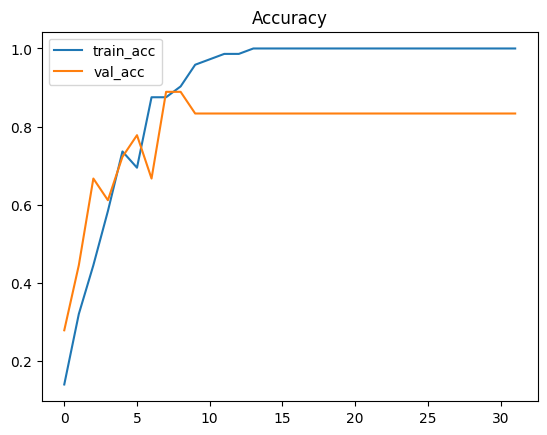

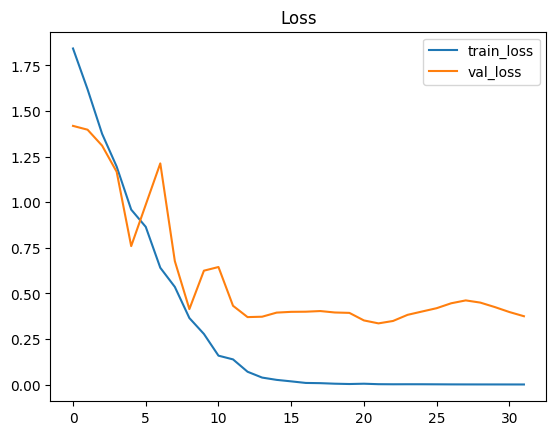

In [ ]:

import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()